In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
pd.set_option('display.max_columns', None) 

In [3]:
original_df = pd.read_csv('3.1_dataset_clean.csv')
original_df.head()

,link,address,apartment_name,sector,price,price_sqft,super_area,bedrooms,bathroom,balcony,additional_rooms,age_possession,floor,floor_num,total_floors,furnishing_type,facing,num_parking,features,servant_room,study_room,pooja_room,store_room,luxury_score,luxury_category,parking
0,https://www.99acres.com/2-bhk-bedroom-apartmen...,"Bharat Residency\nJharsa, Gurgaon",bharat residency,jharsa,0.70,5477.3,1278.0000,2,2,2,Store Room,1 to 5 year old,Ground of 4 Floors,0,4,Semifurnished,na,1 Open,"['Security / Fire Alarm', 'Lift(s)', 'High Cei...",0,0,0,1,21,medium,1
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,"GLS Arawali Homes\nSohna, Gurgaon",gls arawali homes,sohna,0.38,5569.0,682.3526,2,2,2,Others,1 to 5 year old,6th of 13 Floors,6,13,Semifurnished,East,"1 Covered, 1 Open","['Security / Fire Alarm', 'Power Back-up', 'Fe...",0,0,0,0,35,medium,2
2,https://www.99acres.com/2-bhk-bedroom-apartmen...,"CHD Avenue 71\nSector 71, Gurgaon",chd avenue 71,sector 71,1.35,11268.8,1198.0000,2,2,2,NaN,10+ year old,1st of 14 Floors,1,14,Unfurnished,North,1 Covered,"['Centrally Air Conditioned', 'Water purifier'...",0,0,0,0,71,high,1
3,https://www.99acres.com/4-bhk-bedroom-apartmen...,"signature avenue\nSector 82, Gurgaon",signature avenue,sector 82,3.40,94444.4,360.0000,4,4,2,"Pooja Room,Servant Room",0 to 1 year old,4th of 4 Floors,4,4,Furnished,North-East,2 Covered,"['Power Back-up', 'Lift(s)', 'Water purifier',...",1,0,1,0,28,medium,2
4,https://www.99acres.com/2-bhk-bedroom-apartmen...,"Signature Global Park\nSohna, Gurgaon",signature global park,sohna,0.95,8920.2,1065.0000,2,2,2,NaN,0 to 1 year old,1st of 4 Floors,1,4,Semifurnished,na,1 Covered,"['Lift(s)', 'Swimming Pool', 'Park', 'Fitness ...",0,0,0,0,18,low,1


In [4]:
df = original_df.drop(columns = ['link','address','additional_rooms','floor', 'num_parking','features'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5593 entries, 0 to 5592
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   apartment_name   5593 non-null   object 
 1   sector           5593 non-null   object 
 2   price            5593 non-null   float64
 3   price_sqft       5593 non-null   float64
 4   super_area       5593 non-null   float64
 5   bedrooms         5593 non-null   int64  
 6   bathroom         5593 non-null   int64  
 7   balcony          5593 non-null   object 
 8   age_possession   5593 non-null   object 
 9   floor_num        5593 non-null   int64  
 10  total_floors     5593 non-null   int64  
 11  furnishing_type  5593 non-null   object 
 12  facing           5593 non-null   object 
 13  servant_room     5593 non-null   int64  
 14  study_room       5593 non-null   int64  
 15  pooja_room       5593 non-null   int64  
 16  store_room       5593 non-null   int64  
 17  luxury_score  

In [6]:
#check for duplicates
df.duplicated().sum()

7

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.columns

Index(['apartment_name', 'sector', 'price', 'price_sqft', 'super_area',
       'bedrooms', 'bathroom', 'balcony', 'age_possession', 'floor_num',
       'total_floors', 'furnishing_type', 'facing', 'servant_room',
       'study_room', 'pooja_room', 'store_room', 'luxury_score',
       'luxury_category', 'parking'],
      dtype='object')

### apartment_name

In [9]:
df['apartment_name'].isna().sum()

0

In [10]:
df['apartment_name'].value_counts(ascending=False)

apartment_name
shapoorji pallonji joyville gurugram    118
m3m heights                             118
tata primanti                            96
m3m woodshire                            85
adani m2k oyster grande                  79
                                       ... 
kw royal court                            1
ramprastha rise                           1
jeevan tara apartment                     1
sagavi apartments                         1
karamvir towers                           1
Name: count, Length: 505, dtype: int64

In [11]:
df['apartment_name'].value_counts(normalize=True).cumsum().head(60)

apartment_name
shapoorji pallonji joyville gurugram            0.021124
m3m heights                                     0.042248
tata primanti                                   0.059434
m3m woodshire                                   0.074651
adani m2k oyster grande                         0.088793
sobha city                                      0.102936
tulip yellow                                    0.115109
m3m golfestate                                  0.127282
ramprastha the edge towers                      0.139456
ats triumph                                     0.151450
paras dews                                      0.163444
godrej meridien                                 0.175439
experion windchants                             0.186001
puri emerald bay                                0.196384
ats tourmaline                                  0.206409
pyramid urban homes                             0.216434
emaar mgf the palm drive                        0.226280
experion the hea

<Axes: xlabel='apartment_name'>

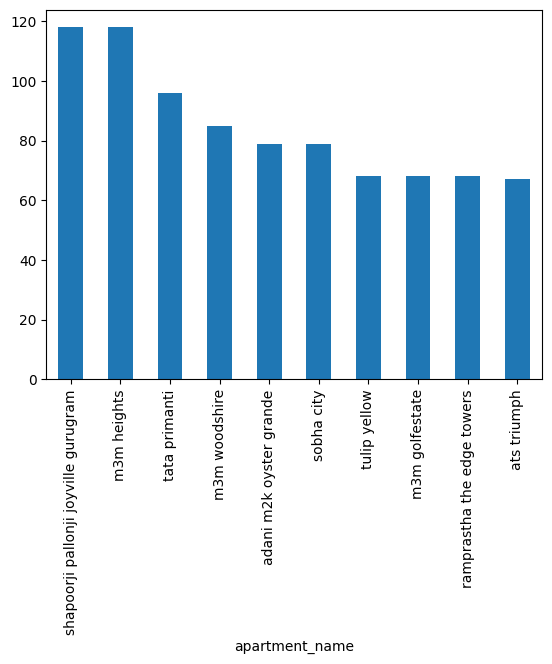

In [12]:
df['apartment_name'].value_counts().head(10).plot(kind='bar')

#### Observations
- No nan values
- Total of 505 societies -> high cardinality
- Around 60 societies contribute to 50% of the data


### sector

In [13]:
df['sector'].isna().sum()

0

In [14]:
df['sector'].unique()

array(['jharsa', 'sohna', 'sector 71', 'sector 82', 'sector 89',
       'sector 86', 'sector 102', 'sector 37d', 'sector 68', 'sector 67',
       'sector 106', 'sector 63a', 'sector-33 sohna', 'sector 70',
       'sector 69', 'sector 65', 'sector 48', 'sector 37c', 'sector 81',
       'sector 95', 'sector 79', 'sector 88a', 'sector 95a', 'sector 93',
       'ardee city', 'sector 61', 'gwal pahari', 'sector 107',
       'sector 66', 'sector 92', 'sector 90', 'sector 83', 'sector 33',
       'sector 49', 'sector 14', 'sector 1a imt manesar', 'sector 54',
       'sector-2 sohna', 'sector 104', 'sector 84', 'sector 63',
       'sector 91', 'dlf phase 4', 'sector 76', 'sector 36 sohna',
       'dlf phase 5', 'sector 99', 'sector 77', 'sector 67a', 'sector 62',
       'sector 99a', 'malibu town', 'sector 105', 'golf course ext road',
       'sector 70a', 'sector 113', 'wazirabad', 'sector 108', 'sector 3',
       'nirvana country', 'old dlf colony', 'nawada fatehpur',
       'sector 109', 's

In [15]:
df['sector'].value_counts()

sector
sector 65          311
sector 102         301
sector 69          174
sector 81          167
sector 37d         163
                  ... 
sector-4 sohna       1
sector-5 sohna       1
sector 41            1
new colony           1
uppals southend      1
Name: count, Length: 140, dtype: int64

In [16]:
df['sector'].value_counts(normalize= True).cumsum().head(18)

sector
sector 65     0.055675
sector 102    0.109560
sector 69     0.140709
sector 81     0.170605
sector 37d    0.199785
sector 108    0.228428
sector 109    0.256355
sector 104    0.283208
sector 79     0.309166
sector 106    0.335124
sector 86     0.359649
sector 84     0.383459
sector 66     0.406373
sector 70a    0.428750
sector 90     0.449159
sohna         0.469030
sector 107    0.487827
sector 72     0.505908
Name: proportion, dtype: float64

<Axes: xlabel='sector'>

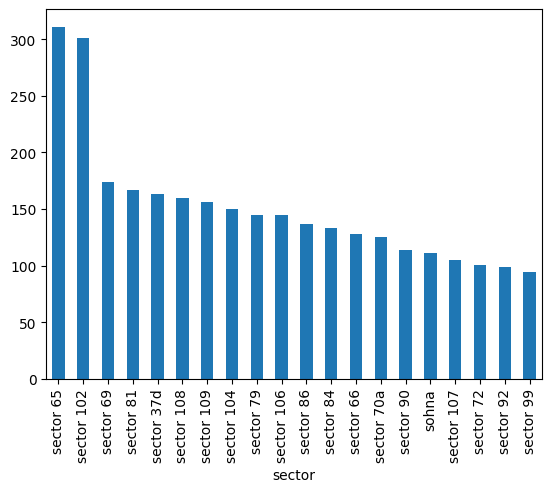

In [17]:
df['sector'].value_counts().head(20).plot(kind='bar')

#### observations
- no nan values
- some entries in sector are not correct (nirvana country,jharsa etc)
- total 140 unique values -> high cardinality
- 18 sectors contribute to 50% data -> model may develop bias

### price

In [18]:
df['price'].isna().sum()

0

In [19]:
df['price'].describe()

count    5586.000000
mean        2.907978
std         2.079873
min         0.270000
25%         1.700000
50%         2.410000
75%         3.550000
max        27.260000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

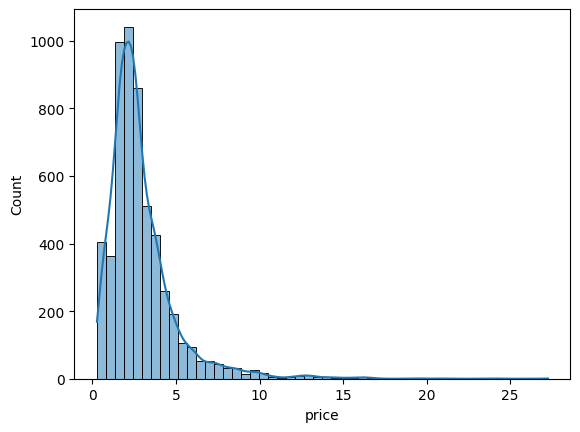

In [20]:
sns.histplot(df['price'] , kde= True ,bins = 50)

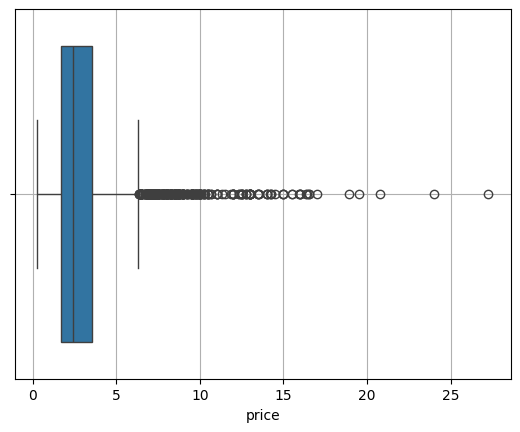

In [21]:
sns.boxplot(x= df['price'])
plt.grid()

In [22]:
#skewness and kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness , kurtosis)

2.9126813416794075 14.941074062823335


In [23]:
df.sort_values('price', ascending=True). head(5)

,apartment_name,sector,price,price_sqft,super_area,bedrooms,bathroom,balcony,age_possession,floor_num,total_floors,furnishing_type,facing,servant_room,study_room,pooja_room,store_room,luxury_score,luxury_category,parking
2267,mahindra aura,sector 110 a,0.2700,8450.7,319.5000,1,1,1,5 to 10 year old,6,10,na,North-East,0,0,0,0,18,low,1
110,sagar homes 5,sector 105,0.2800,28169.0,99.4000,2,2,1,1 to 5 year old,3,4,Unfurnished,East,0,0,0,0,3,low,1
43,hcbs sports ville,sohna,0.3000,5063.4,592.4875,1,1,1,1 to 5 year old,3,9,Furnished,na,0,0,0,0,20,medium,1
5024,terra heritage gurgaon iffco chowk,iffco chowk,0.3295,2865.2,1150.0000,2,2,3,0 to 1 year old,1,14,Furnished,East,0,0,0,0,52,high,1
1864,breez global heights,sector-33 sohna,0.3400,5666.7,600.0000,1,1,1,1 to 5 year old,8,10,Semifurnished,North-East,0,0,0,1,32,medium,1


In [24]:
df.sort_values('price',ascending=False).head(5)

,apartment_name,sector,price,price_sqft,super_area,bedrooms,bathroom,balcony,age_possession,floor_num,total_floors,furnishing_type,facing,servant_room,study_room,pooja_room,store_room,luxury_score,luxury_category,parking
2702,tulip monsella,sector 53,27.26,36997.8,7368.0,5,7,3+,1 to 5 year old,35,36,Semifurnished,na,1,1,1,1,68,high,4
1968,dlf the crest,sector 54,24.00,59671.8,4022.0,4,5,3+,1 to 5 year old,10,36,Semifurnished,West,0,0,0,0,34,medium,2
1632,trump tower,sector 65,20.80,34380.2,6050.0,4,4,3,under construction,27,47,Semifurnished,North-West,1,0,1,0,36,medium,0
5036,dlf the crest,sector 54,19.50,55256.4,3529.0,4,6,3,1 to 5 year old,6,36,Semifurnished,North-East,1,1,0,0,29,medium,3
3412,pioneer araya,sector 62,18.90,34276.4,5514.0,5,7,3+,1 to 5 year old,25,34,Semifurnished,North,1,1,1,1,71,high,7


In [25]:
#quantile analysis
quantiles = df['price'].quantile([0.1, 0.25, 0.50 , 0.95 , 0.99])
print(quantiles)

0.10     1.10
0.25     1.70
0.50     2.41
0.95     6.70
0.99    11.33
Name: price, dtype: float64


In [26]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

1.8499999999999999

In [27]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.075 6.324999999999999


In [28]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(312, 20)

In [29]:
outliers['price'].describe()

count    312.000000
mean       9.226923
std        2.978819
min        6.340000
25%        7.200000
50%        8.250000
75%       10.000000
max       27.260000
Name: price, dtype: float64

([<matplotlib.axis.XTick at 0x177c1ec60>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(20, 0, '20'),
  Text(50, 0, '50')])

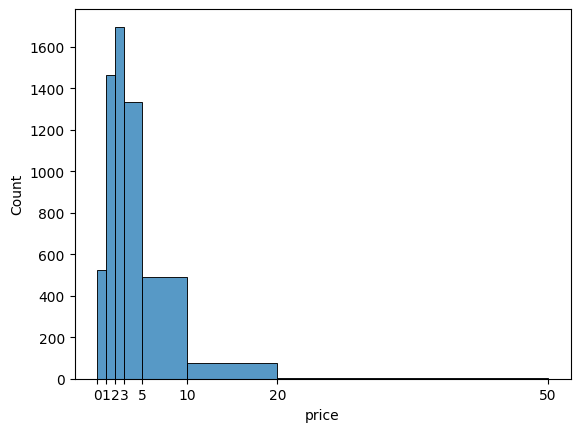

In [30]:
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
sns.histplot(df['price'], bins=[0, 1, 2, 3, 5, 10, 20, 50] )
plt.xticks([0,1,2,3,5,10,20,50])

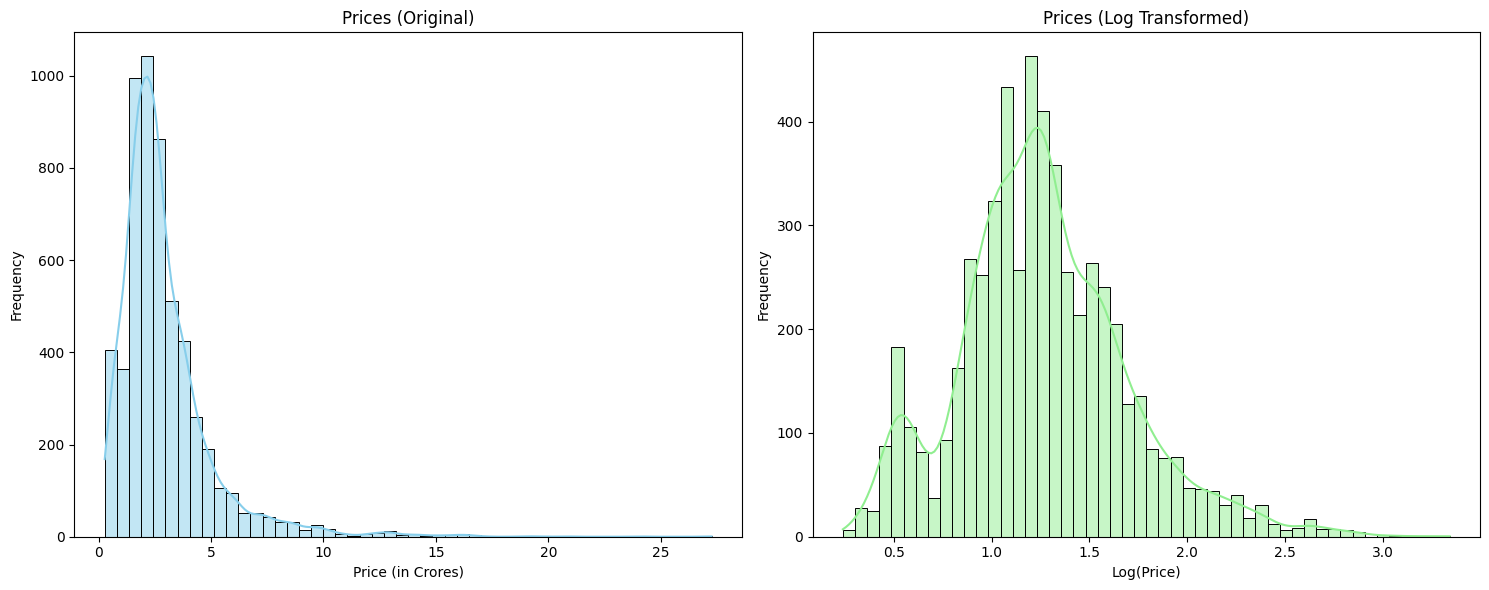

In [31]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation -> log 1p used to avoid negative values
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

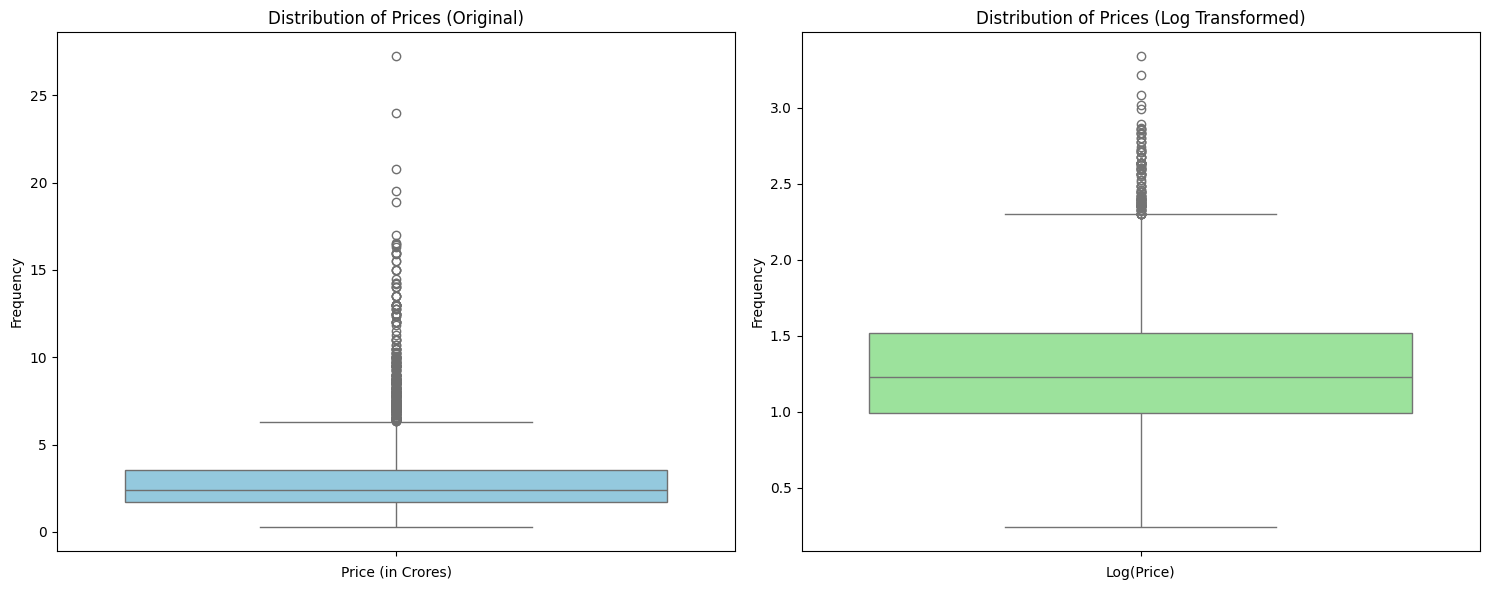

In [32]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### observations
- no nan values
- Mean = 2.907978
- IQR is 1.7Cr to 3.55Cr
- distribution shows that most houses priced below 5Cr
- Data is right skewed -> log transformations might be helpful -> seems to be bimodal
- skewness = 2.9126813416794075 -> positive skew in data
- kurtosis = 14.94 -> since value>3 -> heavy tailed -> presence of outliers
- based on quantile analysis -> price > 6.7Cr can be considered outliers (312 potential outliers)

### price_sqft

In [33]:
df['price_sqft'].isna().sum()

0

In [34]:
df['price_sqft'].describe()

count      5586.000000
mean      14921.391103
std       16113.451388
min        2865.200000
25%        9913.125000
50%       12349.650000
75%       16194.625000
max      406051.700000
Name: price_sqft, dtype: float64

<Axes: xlabel='price_sqft', ylabel='Count'>

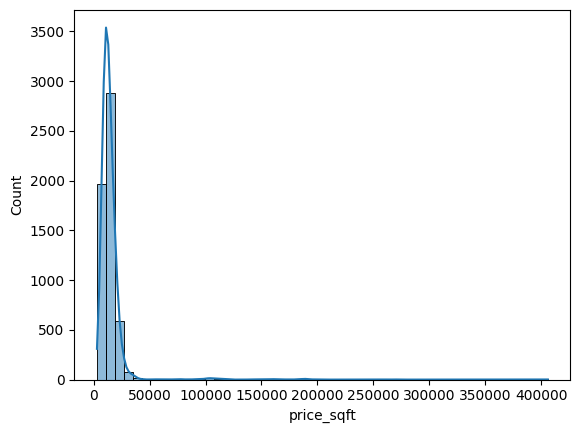

In [35]:
sns.histplot(df['price_sqft'] , kde=True , bins =50)

<Axes: xlabel='price_sqft'>

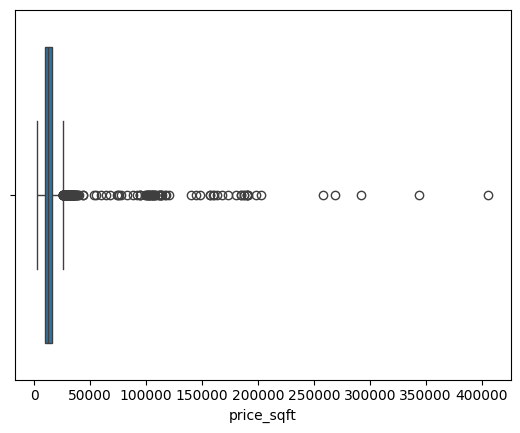

In [36]:
sns.boxplot(x= df['price_sqft'])

In [37]:
#check for outlier using IQR

Q1 = df['price_sqft'].describe()['25%']
Q3 = df['price_sqft'].describe()['75%']
IQR = Q3-Q1
IQR


6281.5

In [38]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

490.875 25616.875


In [39]:
df['price_sqft'].quantile([0.1,0.25,0.50,0.90,0.95,0.99])

0.10     8290.800
0.25     9913.125
0.50    12349.650
0.90    19908.500
0.95    23965.100
0.99    94322.085
Name: price_sqft, dtype: float64

#### Observations 
 - clear presence of outlier -> values> **25616** can be considered outliers
 - right skewed data

### Observations price_sqft
- looks like some sectors[sector 76, b block sushant lok phase 1, sector 105, sushant lok phase 3] have very high mean price/sqft - > presence of outliers/ problem in data
- Looking more at it, there is prblem in data. Some flats where area was in sq.m has been considered as sq.ft leading to outliers in price_sqft and area cols.
- Data to be corrected by scraping again the problematic rows

<Axes: ylabel='price_sqft'>

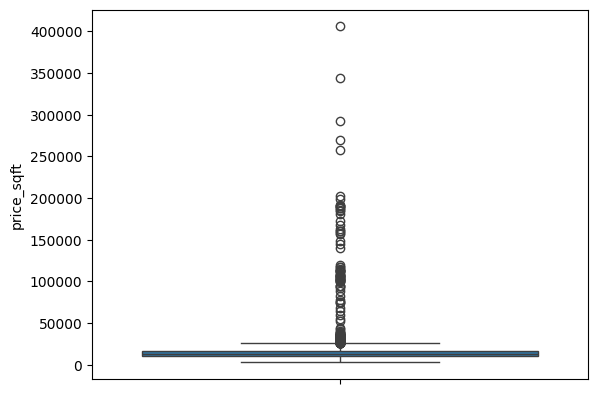

In [40]:
sns.boxplot(data= df , y= 'price_sqft')

### super_area

In [41]:
df['super_area'].isna().sum()

0

In [42]:
df['super_area'].describe()

count     5586.000000
mean      2047.677080
std        919.775456
min         60.000000
25%       1534.000000
50%       1929.890000
75%       2408.000000
max      10000.000000
Name: super_area, dtype: float64

<Axes: xlabel='super_area', ylabel='Count'>

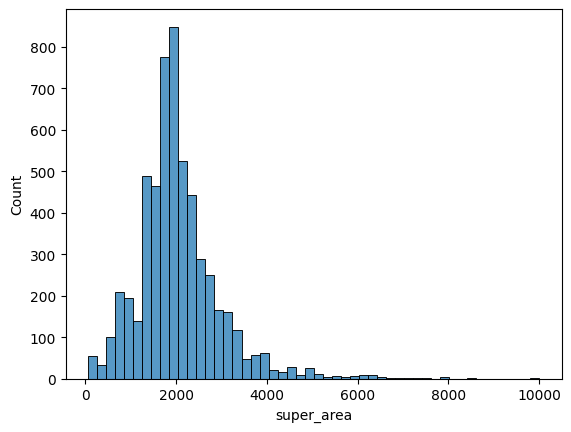

In [43]:
sns.histplot(df['super_area'] , bins = 50)

<Axes: xlabel='super_area'>

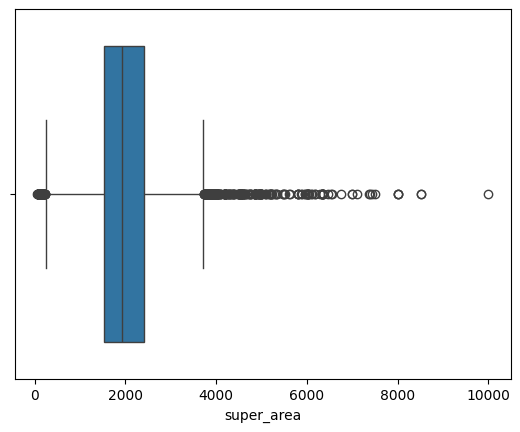

In [44]:
sns.boxplot(x= df['super_area'], )

#### Observations
- clear presence of outliers in both lower and upper bound
- need to check if data error or true outliers
- most houses present in range of 1500-2500 sq.ft range

#### bedrooms

In [45]:
df['bedrooms'].isna().sum()

0

In [46]:
df['bedrooms'].describe()

count    5586.000000
mean        2.962585
std         0.713996
min         1.000000
25%         3.000000
50%         3.000000
75%         3.000000
max         6.000000
Name: bedrooms, dtype: float64

<Axes: xlabel='bedrooms', ylabel='Count'>

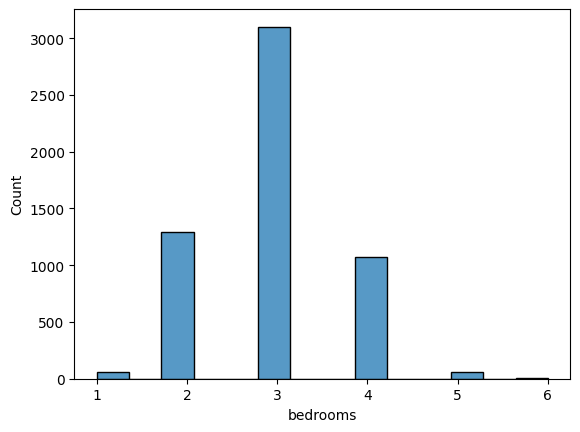

In [47]:
sns.histplot(df['bedrooms'])

<Axes: ylabel='proportion'>

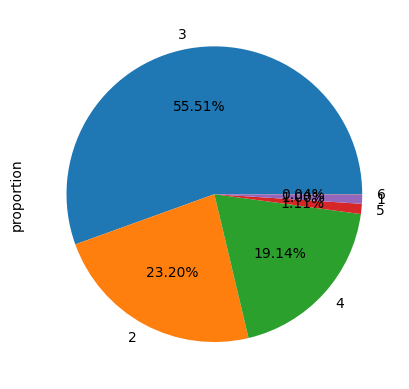

In [48]:
df['bedrooms'].value_counts(normalize= True).plot(kind = 'pie' , autopct = '%0.2f%%')

#### Observations
- no nan
- more than 50% flats have 3 bedrooms -> chance of imbalanced dataset?
- no outliers
- data clean

### age_possession

In [49]:
df['age_possession'].isna().sum()

0

In [50]:
df['age_possession'].value_counts()

age_possession
1 to 5 year old       3203
0 to 1 year old        998
5 to 10 year old       854
under construction     318
10+ year old           213
Name: count, dtype: int64

###

In [51]:
df['floor_num'].isna().sum()

0

In [52]:
df['floor_num'].value_counts(normalize=True).sort_index().cumsum()

floor_num
0     0.022019
1     0.059792
2     0.107769
3     0.165414
4     0.222700
5     0.294665
6     0.366452
7     0.447189
8     0.535983
9     0.597028
10    0.683136
11    0.729502
12    0.785714
13    0.791443
14    0.825636
15    0.861976
16    0.882026
17    0.898317
18    0.917472
19    0.929288
20    0.945399
21    0.953097
22    0.961690
23    0.966702
24    0.970820
25    0.976907
26    0.980308
27    0.983172
28    0.985858
29    0.988364
30    0.990512
31    0.992481
32    0.993376
33    0.994808
34    0.995883
35    0.996778
36    0.997136
37    0.997673
38    0.998031
39    0.998389
40    0.999105
42    0.999284
45    0.999821
46    1.000000
Name: proportion, dtype: float64

### total_floor

In [53]:
df['total_floors'].isna().sum()

0

In [54]:
df['total_floors'].value_counts(normalize=True).sort_index().cumsum()
# 50% house under 19 floors tall

total_floors
0     0.000358
1     0.000895
2     0.007161
3     0.017544
4     0.062657
5     0.070354
6     0.072324
7     0.076262
8     0.083781
9     0.088614
10    0.101325
11    0.118869
12    0.155926
13    0.194773
14    0.343537
15    0.367168
16    0.386323
17    0.423380
18    0.470999
19    0.555854
20    0.592732
21    0.627282
22    0.658074
23    0.667920
24    0.716076
25    0.735947
26    0.776942
27    0.801468
28    0.813641
29    0.847834
30    0.868242
31    0.872359
32    0.894200
33    0.903688
34    0.935732
35    0.946831
36    0.949875
38    0.950949
39    0.958826
40    0.981024
41    0.981919
42    0.986932
43    0.987648
45    0.988185
47    0.993555
48    0.996778
51    1.000000
Name: proportion, dtype: float64

In [55]:
df['total_floors'].describe()

count    5586.000000
mean       20.047977
std         9.216205
min         0.000000
25%        14.000000
50%        19.000000
75%        26.000000
max        51.000000
Name: total_floors, dtype: float64

In [56]:
df[df['total_floors'] == 0]

,apartment_name,sector,price,price_sqft,super_area,bedrooms,bathroom,balcony,age_possession,floor_num,total_floors,furnishing_type,facing,servant_room,study_room,pooja_room,store_room,luxury_score,luxury_category,parking
121,pyramid urban homes,sector 70a,0.75,8971.3,836.0,2,2,1,1 to 5 year old,0,0,Semifurnished,na,0,0,0,0,35,medium,0
4725,godrej arista,sector 79,3.30,14042.6,2350.0,3,3,3,under construction,0,0,na,na,0,0,0,0,35,medium,2


#### Observations
- no nan 
- 50% house under 19 floors tall

### furnishing_type

In [57]:
df['furnishing_type'].isna().sum()

0

In [58]:
df['furnishing_type'].value_counts()

furnishing_type
Semifurnished    3937
Unfurnished      1086
Furnished         301
na                262
Name: count, dtype: int64

In [59]:
df['facing'].isna().sum()

0

In [60]:
df['facing'].value_counts()

facing
East          1477
North-East    1417
North          833
na             620
North-West     348
West           303
South          257
South-East     186
South-West     145
Name: count, dtype: int64

In [61]:
df.columns

Index(['apartment_name', 'sector', 'price', 'price_sqft', 'super_area',
       'bedrooms', 'bathroom', 'balcony', 'age_possession', 'floor_num',
       'total_floors', 'furnishing_type', 'facing', 'servant_room',
       'study_room', 'pooja_room', 'store_room', 'luxury_score',
       'luxury_category', 'parking'],
      dtype='object')

In [62]:
df[['servant_room', 'study_room' , 'pooja_room', 'store_room']]

,servant_room,study_room,pooja_room,store_room
0,0,0,0,1
1,0,0,0,0
2,0,0,0,0
3,1,0,1,0
4,0,0,0,0
...,...,...,...,...
5588,0,0,0,0
5589,1,1,0,0
5590,1,0,0,0
5591,0,0,0,0


Text(0.5, 1.0, 'study room')

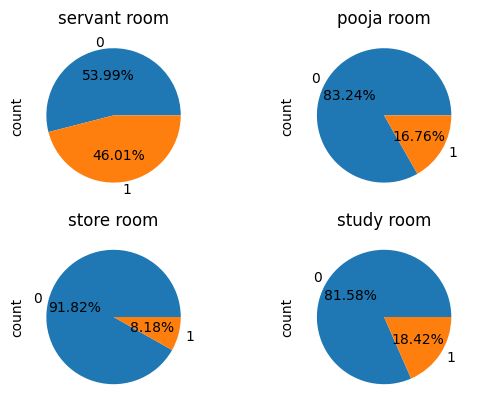

In [63]:
plt.subplot(2,2,1)
df['servant_room'].value_counts().plot(kind = 'pie' , autopct = '%0.2f%%')
plt.title('servant room')
plt.subplot(2,2,2)
df['pooja_room'].value_counts().plot(kind = 'pie' , autopct = '%0.2f%%')
plt.title('pooja room')
plt.subplot(2,2,3)
df['store_room'].value_counts().plot(kind = 'pie' , autopct = '%0.2f%%')
plt.title('store room')
plt.subplot(2,2,4)
df['study_room'].value_counts().plot(kind = 'pie' , autopct = '%0.2f%%')
plt.title('study room')

In [64]:
df['parking'].isna().sum()

0

<Axes: xlabel='parking', ylabel='Count'>

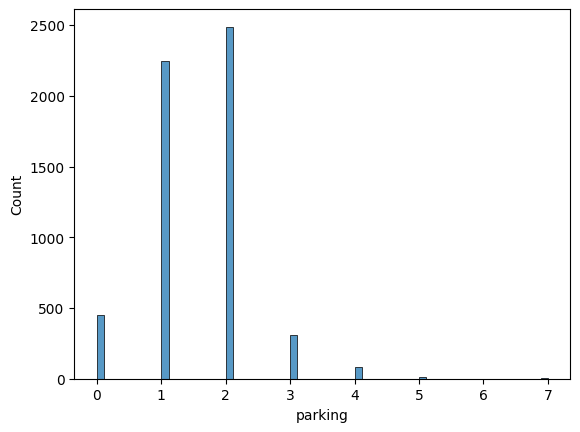

In [65]:
sns.histplot(df['parking'])

<Axes: ylabel='count'>

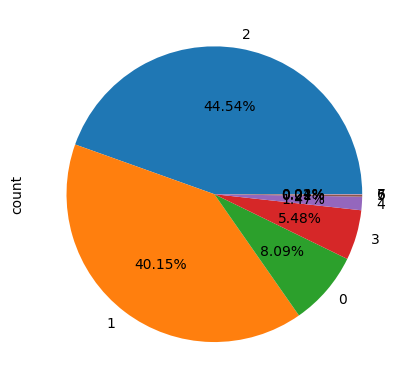

In [66]:
df['parking'].value_counts().plot(kind='pie' , autopct = '%0.2f%%')

In [67]:
px.pie(data_frame= df['parking'].value_counts(), values= df['parking'].value_counts().values , hover_name= df['parking'].value_counts().index,)


In [68]:
df['luxury_score'].isna().sum()

0

In [69]:
df['luxury_score'].describe()

count    5586.000000
mean       46.006624
std        16.285659
min         2.000000
25%        35.000000
50%        44.000000
75%        60.000000
max        71.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

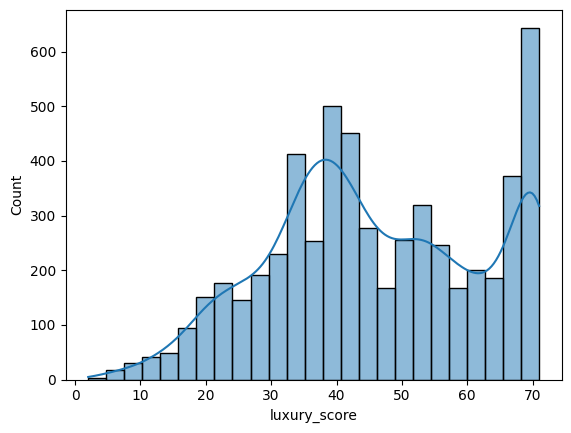

In [70]:
sns.histplot(df['luxury_score'] , kde=True)

<Axes: xlabel='luxury_category', ylabel='Count'>

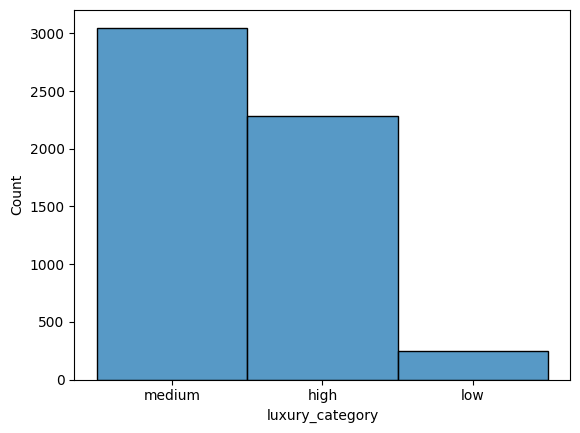

In [71]:
sns.histplot(df['luxury_category'])

In [72]:
df['luxury_score'].quantile([0.1,0.2,0.4,0.5,0.6,0.7,0.8,0.9, 0.95, 0.99])

0.10    24.0
0.20    32.0
0.40    40.0
0.50    44.0
0.60    50.0
0.70    56.0
0.80    64.0
0.90    71.0
0.95    71.0
0.99    71.0
Name: luxury_score, dtype: float64

In [73]:
df.groupby('luxury_category')['price'].mean()

luxury_category
high      3.323702
low       1.840689
medium    2.683386
Name: price, dtype: float64